<a href="https://colab.research.google.com/github/AlishbaMalik687-svg/AI-ML_Decision-Tree-Model/blob/master/ML_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Model: Decision Tree
*   Dataset: Heart Disease



Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

Uploading Dataset

In [ ]:
df=pd.read_csv('/content/HeartDiseaseTrain-Test.csv')
df.head(5)

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


Dataset Information

In [ ]:
df.info()
print('\n shape',df.shape)
print('\n Columns:',df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

Split 'Target' and 'Features'

In [ ]:
A=df.drop(['sex','target'], axis=1)
b=df['target']

A.head()
b.head()

,target
0,0
1,0
2,0
3,0
4,0


Train Test Split

In [ ]:
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=42)
print('Shape of A_train:', A_train.shape)
print('Shape of A_test:', A_test.shape)
print('Shape of b_train:', b_train.shape)
print('Shape of b_test:', b_test.shape)

Shape of A_train: (820, 12)
Shape of A_test: (205, 12)
Shape of b_train: (820,)
Shape of b_test: (205,)


Checking Type of Training Data

In [ ]:
A_train.dtypes

,0
age,int64
chest_pain_type,object
resting_blood_pressure,int64
cholestoral,int64
fasting_blood_sugar,object
rest_ecg,object
Max_heart_rate,int64
exercise_induced_angina,object
oldpeak,float64
slope,object


Standard Scaler

In [ ]:
A_train=A_train.select_dtypes(include=['float64','int64'])
A_test=A_test.select_dtypes(include=['float64','int64'])

scaler=StandardScaler()
A_train=scaler.fit_transform(A_train)
A_test=scaler.transform(A_test)


Model: Decision Tree

In [ ]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(A_train,b_train)
dt_pred=dt.predict(A_test)

print('Accuracy Score:',accuracy_score(b_test,dt_pred))
print('Confusion Matrix:\n',confusion_matrix(b_test,dt_pred))
print('Classification Report:\n',classification_report(b_test,dt_pred))

Accuracy Score: 0.9853658536585366
Confusion Matrix:
 [[102   0]
 [  3 100]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Visualization

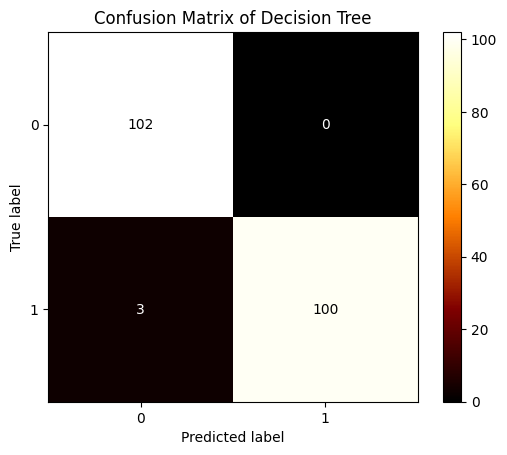

In [ ]:
cm=confusion_matrix(b_test,dt_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt.classes_)
disp.plot(cmap='afmhot')
plt.title('Confusion Matrix of Decision Tree')
plt.show()